# Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **_Hardani Ismu Nabil_** | _hardani.ismu.n@gmail.com_ | **_ND Stadium Collaborative Project 2025/2026_** |

# Notebook Target Definition

* **GOAL** Analyze the correlated dataset for Browsing Test
* **GENERATES** metric graphs such as the CDFs of Browsing Tests
* The C-TextOutput section is used to verify the numbers in the paper
* **REQUIRES** SigCap Data Processing notebooks to be run first! It will create data/process/SigCapCorrelated directory if successful

# ===============================
# ===============================

# A- Notebook Setup

In [1]:
# %pip install matplotlib numpy pandas
# %pip install seaborn
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import os
import pathlib

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Force Matplotlib to use Type 42 (TrueType) fonts instead of Type 3
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Ensure text isn't converted to paths/bitmaps
matplotlib.rcParams['svg.fonttype'] = 'none'

In [3]:
PROJECT_ROOT = pathlib.Path('.').cwd().parent # you can also do it manually, for example ~/repos/NdSta2026


print('='*50, '[DATA DIRECTORY]')
DATA_DIR = PROJECT_ROOT / 'data_processed'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Looking for data in: {DATA_DIR}")


print('- '*25)
print('='*50, '[OUTPUT DIRECTORY]')

# OUTPUT_DIR = PROJECT_ROOT / 'output/output_July1st_dataAnalysis/analysis_browsingStatistics' # CHANGE this into the notebook file name
OUTPUT_DIR = PROJECT_ROOT / 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"All outputs will be in: {OUTPUT_DIR}")

================================================== [DATA DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
Looking for data in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_processed
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================================== [OUTPUT DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
All outputs will be in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/figures


In [4]:
# df_browser = pd.read_csv(DATA_DIR / 'king_metric_browsing_bowl.csv')

df_qp5_browser_merged = pd.read_csv(DATA_DIR / 'df_browser_merged_gd5.csv')
df_qp6_browser_merged = pd.read_csv(DATA_DIR / 'df_browser_merged_gd6.csv')
df_browser = pd.read_csv(DATA_DIR / 'df_browser_merged_pg.csv')

## A: Filtering

In [5]:
# Label the browser data
df_browser_filtered = df_browser[df_browser['Collection'] == '20260226_preGame_Bowl'].copy()
df_browser_filtered['Label'] = 'Non-game'

# Label the QP5 and QP6 data
df_qp5_filtered = df_qp5_browser_merged[df_qp5_browser_merged['Location_sigcap'] == 'Bowl'].copy()
df_qp5_filtered['Label'] = 'Game'

df_qp6_filtered = df_qp6_browser_merged[df_qp6_browser_merged['Location_sigcap'] == 'Bowl'].copy()
df_qp6_filtered['Label'] = 'Game'

In [6]:
combined_df = pd.concat([df_browser_filtered, df_qp5_filtered, df_qp6_filtered], ignore_index=True)
del df_browser_filtered, df_qp5_filtered, df_qp6_filtered
gc.collect()

# Verify the counts to make sure everything moved over
print(combined_df['Label'].value_counts())

Label
Game        755
Non-game    335
Name: count, dtype: int64


In [7]:
combined_df[['operator', 'Label']].value_counts().sort_index()

operator  Label   
AT&T      Game        150
          Non-game     80
T-Mobile  Game        108
          Non-game     65
Verizon   Game        130
          Non-game     60
Wi-Fi 5   Non-game      5
Wi-Fi 6   Game        367
          Non-game    125
Name: count, dtype: int64

In [8]:
combined_df['operator'] = combined_df['operator'].replace('Wi-Fi 6', 'Wi-Fi 6 GHz')
combined_df['operator'] = combined_df['operator'].replace('Wi-Fi 5', 'Wi-Fi 5 GHz')

# ===============================
# ===============================

# B- Visualization (Completed Only) (RUN Together)

### B: configs

In [9]:
df_browser_merged = combined_df[combined_df['Test Status'] == 'Completed'].copy()

df_browser_merged.rename(columns={'Round Trip Time (RTT)': 'Round Trip Time'}, inplace=True)

METRIC_COL = 'Round Trip Time'
METRIC_COL_UNIT = 'ms'

RAT_COL = 'Label'        ## Change to RAT_COL when we already did the df_browser_merge
SPLIT_COL = 'operator'

In [10]:
COLLECTION_HOST = ['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com']
df_browser_merged = df_browser_merged[df_browser_merged['Host'].isin(COLLECTION_HOST)].copy()

### B: Experiment

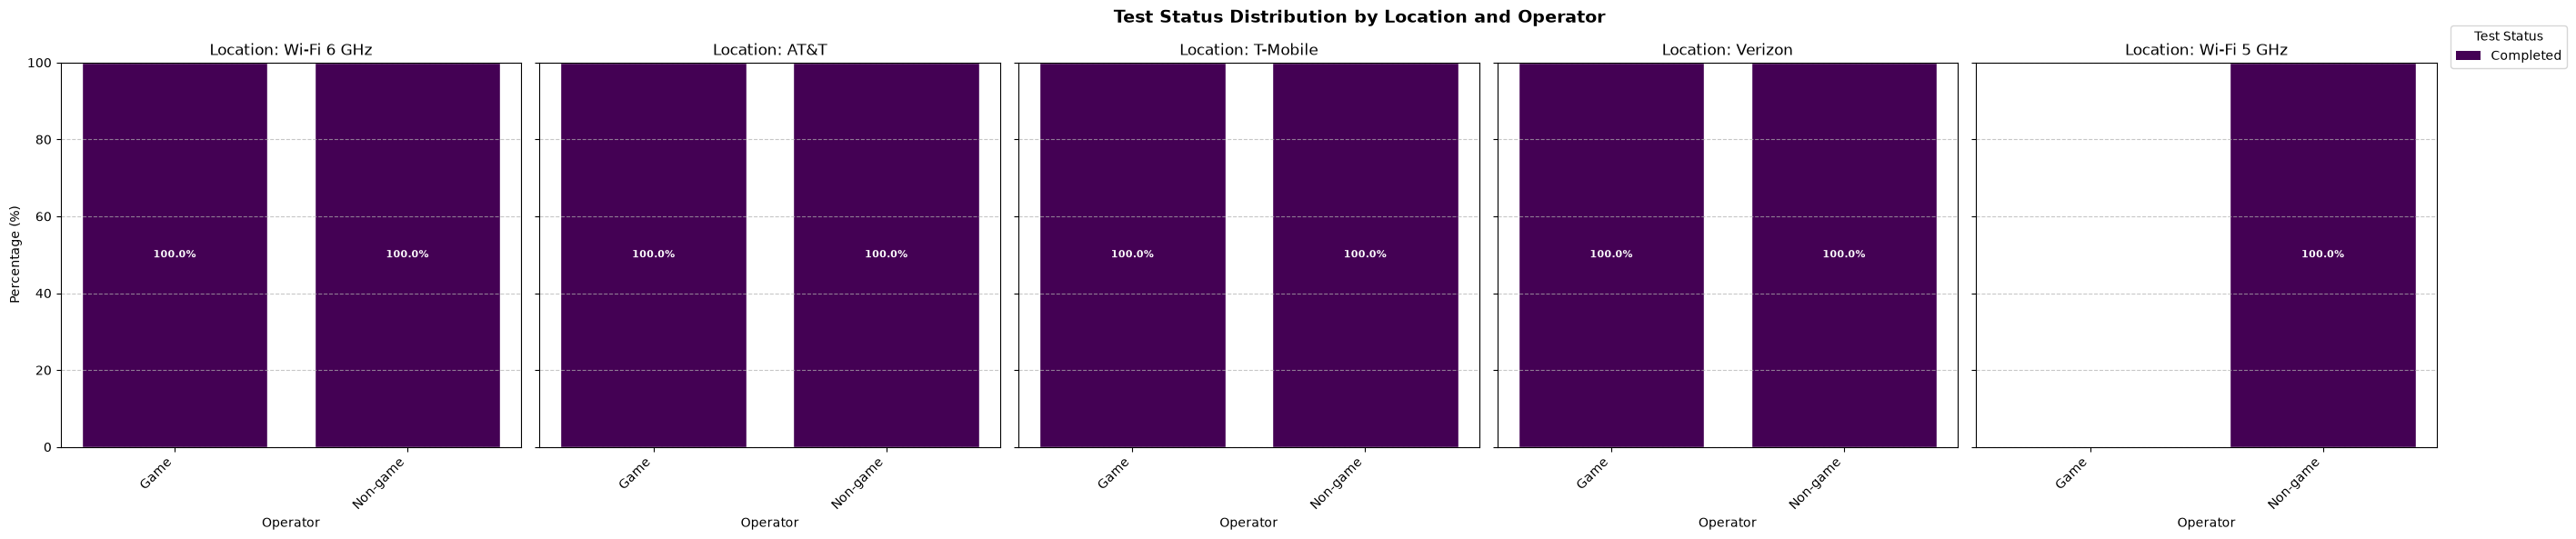

In [11]:
unique_operators = sorted(df_browser_merged[RAT_COL].unique()) # Sort operators
unique_Locations = df_browser_merged[SPLIT_COL].unique()
# unique_Locations = ['Gameday', 'Postgame']

num_Locations = len(unique_Locations)
num_operators = len(unique_operators)

fig, axes = plt.subplots(1, num_Locations, figsize=(num_Locations * 6, 6), sharey=True, squeeze=False)
axes = axes.flatten() # Flatten in case there's only one subplot

all_statuses = df_browser_merged['Test Status'].sort_values().unique()
status_color_map = {status: plt.cm.viridis(i / len(all_statuses)) for i, status in enumerate(all_statuses)}

for c_idx, Location_val in enumerate(unique_Locations):
    ax = axes[c_idx]
    
    operator_x_positions = np.arange(num_operators)
    
    # Prepare data for stacked bars for the current Location
    # This will be a dictionary where keys are statuses and values are lists of percentages for each operator
    stacked_data = {status: [0.0] * num_operators for status in all_statuses}
    
    has_data_for_loc = False
    for op_idx, operator_val in enumerate(unique_operators): # Iterate through sorted operators
        subset_df_browser_merged = df_browser_merged[(df_browser_merged[RAT_COL] == operator_val) & 
                                               (df_browser_merged[SPLIT_COL] == Location_val)]

        if not subset_df_browser_merged.empty:
            has_data_for_loc = True
            status_counts = subset_df_browser_merged['Test Status'].value_counts(normalize=True) * 100
            
            for status in all_statuses:
                stacked_data[status][op_idx] = status_counts.get(status, 0.0)

    if has_data_for_loc:
        bottoms = np.zeros(num_operators)
        for status in all_statuses:
            percentages = stacked_data[status]
            color = status_color_map.get(status, 'gray')
            ax.bar(operator_x_positions, percentages, bottom=bottoms, color=color, edgecolor='white', width=0.8)
            
            # Add percentage labels on bars
            for op_idx, percentage in enumerate(percentages):
                if percentage > 2:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='white', fontsize=8, weight='bold')
                elif percentage > 0:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='black', fontsize=8, weight='bold')
            
            bottoms += np.array(percentages)

        ax.set_xticks(operator_x_positions)
        ax.set_xticklabels(unique_operators, rotation=45, ha='right') # Use sorted unique_operators
        ax.set_title(f'Location: {Location_val}')
        ax.set_ylim(0, 100)
        ax.set_yticks(range(0, 101, 20))
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_xlabel('Operator')
    else:
        ax.set_title(f'{Location_val}')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])

    if c_idx == 0: # Only show y-label on leftmost subplot
        ax.set_ylabel('Percentage (%)')

# Create a single legend for the entire figure
legend_labels = [f'{status}' for status in all_statuses]
legend_handles = [plt.Rectangle((0,0),1,1, fc=status_color_map[status]) for status in all_statuses]

fig.legend(legend_handles, legend_labels, title='Test Status', bbox_to_anchor=(.9, 0.95), loc='upper left', borderaxespad=0.)

fig.suptitle('Test Status Distribution by Location and Operator', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()


### B: ECDF single

In [12]:
OP_COLOR_MAP = {'AT&T': 'tab:blue', 'T-Mobile': 'magenta', 'Verizon': 'darkorange', 'Wi-Fi 5 GHz': 'tab:green', 'Wi-Fi 6 GHz': 'tab:red'}
# OP_COLOR_MAP = 'Set2'
sns.set_style('ticks')

In [13]:
# METRIC_COL = 'Round Trip Time'
# METRIC_COL_UNIT = 'ms'

# RAT_COL = 'Label'        ## Change to RAT_COL when we already did the df_browser_merge
# SPLIT_COL = 'operator'
# # df_browser_merged[['Host','Label']].value_counts().sort_index()
# COLLECTION_HOST = ['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com']
# df_browser_merged = df_browser_merged[df_browser_merged['Host'].isin(COLLECTION_HOST)].copy()

# RAT_COL = 'operator'
# SPLIT_COL = 'Label'

# sorted_operators = df_browser_merged[RAT_COL].sort_values().unique().tolist()
# # sorted_day = ['Game', 'Non-game']
# sorted_day = ['Non-game', 'Game']
# df_browser_merged[f'{METRIC_COL} {METRIC_COL_UNIT}'] = df_browser_merged[METRIC_COL]

# # Calculate P90, P99, and Count per group
# pct_data = df_browser_merged.groupby([RAT_COL, SPLIT_COL])[f'{METRIC_COL} {METRIC_COL_UNIT}'].agg(
#     p90=lambda x: x.quantile(0.90),
#     p99=lambda x: x.quantile(0.99)
# ).reset_index()

# count_data = df_browser_merged.groupby([RAT_COL, SPLIT_COL])[f'{METRIC_COL} {METRIC_COL_UNIT}'].count().reset_index()
# count_data.rename(columns={f'{METRIC_COL} {METRIC_COL_UNIT}': 'Count'}, inplace=True)

# # Merge for single lookup per facet
# stats_data = pct_data.merge(count_data, on=[RAT_COL, SPLIT_COL])

# g = sns.displot(
#     data=df_browser_merged,
#     x=f'{METRIC_COL} {METRIC_COL_UNIT}',
#     kind='ecdf',
#     col=SPLIT_COL,
#     col_order=sorted_day,
#     hue=RAT_COL,
#     height=4.5,
#     aspect=0.85,
#     hue_order=sorted_operators,
#     palette=OP_COLOR_MAP,
# )

# legend_handles = g.legend.legend_handles
# legend_labels = [t.get_text() for t in g.legend.get_texts()]

# for ax_idx, ax in enumerate(g.axes.flat):
#     col_val = g.col_names[ax_idx % len(g.col_names)]
#     facet_stats = stats_data[stats_data[SPLIT_COL] == col_val]

#     labels = []
#     for label in legend_labels:
#         match = facet_stats[facet_stats[RAT_COL] == label]
#         if not match.empty:
#             p90 = match['p90'].iloc[0]
#             p99 = match['p99'].iloc[0]
#             n = match['Count'].iloc[0]
#             labels.append(f"{label} | n={n} \n P90= {p90:.2f}{METRIC_COL_UNIT} \n P99= {p99:.2f}{METRIC_COL_UNIT} ")
#         else:
#             labels.append(f"{label} | n= 0 \n P90= N/A \n P99= N/A ")

#     ax.legend(legend_handles, labels, loc='lower right', reverse=False)

# g.legend.remove()
# g.set_titles(col_template="{col_name}", fontweight='bold', size=16, pad=20)
# g.set_axis_labels(f'{METRIC_COL} ({METRIC_COL_UNIT})', "ECDF", fontsize=16, fontweight='bold')

# for ax in g.axes.flat:
#     ax.xaxis.get_label().set_fontsize(18)
#     ax.xaxis.get_label().set_fontweight('bold')
#     ax.yaxis.get_label().set_fontsize(18)
#     ax.yaxis.get_label().set_fontweight('bold')

# g.fig.tight_layout(rect=[0, 0.03, 1, 0.98])
# # plt.savefig(f'{OUTPUT_DIR}/{METRIC_COL}_{SPLIT_COL}Wise_browsing-ecdf.png', format='png', dpi=300, bbox_inches='tight')
# # plt.show()

### B: ECDF all together **(USED in paper)**

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def plot_ecdf_by_split(
    df,
    metric_col,
    metric_unit,
    split_col,
    rat_col,
    output_dir,
    op_color_map,
    collection_hosts=None,
    x_label=None,
    y_label="ECDF",
    fig_height=4.5,
    fig_aspect=0.85,
    title_fontsize=16,
    axis_fontsize=18,
    dpi=300
):
    """
    Create an ECDF plot faceted by split_col, colored by rat_col.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input data
    metric_col : str
        Name of the metric column to plot
    metric_unit : str
        Unit of the metric (e.g., 'ms', 's', 'Mbps')
    split_col : str
        Column to use for faceting (col parameter in sns.displot)
    rat_col : str
        Column to use for coloring (hue parameter)
    output_dir : str
        Directory to save the output plot
    op_color_map : dict
        Color mapping for rat_col values
    collection_hosts : list, optional
        List of hosts to filter by. If None, no filtering applied
    x_label : str, optional
        X-axis label. If None, defaults to f'{metric_col} ({metric_unit})'
    y_label : str, optional
        Y-axis label. Defaults to "ECDF"
    fig_height : float, optional
        Height of each facet. Defaults to 4.5
    fig_aspect : float, optional
        Aspect ratio of each facet. Defaults to 0.85
    title_fontsize : int, optional
        Font size for facet titles. Defaults to 16
    axis_fontsize : int, optional
        Font size for axis labels. Defaults to 18
    dpi : int, optional
        DPI for saved figure. Defaults to 300
    
    Returns:
    --------
    g : seaborn.FacetGrid
        The created FacetGrid object
    """
    
    # Create a copy to avoid modifying original
    df_plot = df.copy()
    
    # Filter by hosts if provided
    if collection_hosts is not None:
        df_plot = df_plot[df_plot['Host'].isin(collection_hosts)].copy()
    
    # Create metric column with unit for display
    metric_col_display = f'{metric_col} {metric_unit}'
    df_plot[metric_col_display] = df_plot[metric_col]
    
    # Get sorted unique values for ordering
    sorted_rat_values = df_plot[rat_col].sort_values().unique().tolist()
    # sorted_split_values = sorted(df_plot[split_col].unique().tolist())
    sorted_split_values = ['Non-game', 'Game']
    
    # Calculate P90, P99, and Count per group
    pct_data = df_plot.groupby([rat_col, split_col])[metric_col_display].agg(
        p90=lambda x: x.quantile(0.90),
        p99=lambda x: x.quantile(0.99),
        med='median'
    ).reset_index()
    
    count_data = df_plot.groupby([rat_col, split_col])[metric_col_display].count().reset_index()
    count_data.rename(columns={metric_col_display: 'Count'}, inplace=True)
    
    # Merge for single lookup per facet
    stats_data = pct_data.merge(count_data, on=[rat_col, split_col])
    
    # Create the plot
    g = sns.displot(
        data=df_plot,
        x=metric_col_display,
        kind='ecdf',
        col=split_col,
        col_order=sorted_split_values,
        hue=rat_col,
        height=fig_height,
        aspect=fig_aspect,
        hue_order=sorted_rat_values,
        palette=op_color_map,
    )
    
    # Get legend handles and labels
    legend_handles = g.legend.legend_handles
    legend_labels = [t.get_text() for t in g.legend.get_texts()]

    # Update legend for each facet with statistics
    for ax_idx, ax in enumerate(g.axes.flat):
        col_val = g.col_names[ax_idx % len(g.col_names)]
        facet_stats = stats_data[stats_data[split_col] == col_val]
        
        labels = []
        for label in legend_labels:
            match = facet_stats[facet_stats[rat_col] == label]
            if not match.empty:
                p90 = match['p90'].iloc[0]
                # p99 = match['p99'].iloc[0]
                med = match['med'].iloc[0]
                n = match['Count'].iloc[0]
                # labels.append(f"{label} | n={n} \n P90= {p90:.2f}{metric_unit} \n Med= {med:.2f}{metric_unit}")
                labels.append(f"{label} | n={n} \n P90= {p90:.2f} | Med= {med:.2f}")
            else:
                # labels.append(f"{label} | n=0 | P90= N/A | Med= N/A")
                labels.append(f"{label} | n=0 \n P90= N/A | Med= N/A")
        
        ax.legend(legend_handles, labels, loc='lower right', reverse=False, fontsize=axis_fontsize-4, framealpha=0.4, labelspacing=0.7)
    
    # Remove the original legend
    g.legend.remove()
    
    # Set titles and labels
    g.set_titles(col_template="{col_name}", fontweight='bold', size=title_fontsize, pad=20)
    
    if x_label is None:
        x_label = f'{metric_col} ({metric_unit})'
    g.set_axis_labels(x_label, y_label, fontsize=axis_fontsize+8, fontweight='bold')
    # plt.xlim(0, 75)
    
    # Adjust axis label fonts
    for ax in g.axes.flat:
        ax.tick_params(axis='both', which='major', labelsize=axis_fontsize)

        ax.xaxis.get_label().set_fontsize(axis_fontsize+2)
        ax.xaxis.get_label().set_fontweight('bold')
        ax.yaxis.get_label().set_fontsize(axis_fontsize+2)
        ax.yaxis.get_label().set_fontweight('bold')
        
    
    # Adjust layout and save
    g.fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.savefig(f'{output_dir}/testStatusCompleted_qoe_{metric_col}_{split_col}Wise_browsing-ecdf-v4.pdf', 
                format='pdf', dpi=dpi, bbox_inches='tight')
    plt.show()
    return g


# # Example usage for different metrics:

# # Example 1: Round Trip Time in ms
# g1 = plot_ecdf_by_split(
#     df=df_browser_merged,
#     metric_col='Round Trip Time',
#     metric_unit='ms',
#     split_col='Label',  # or 'operator' depending on what you want
#     rat_col='operator',
#     output_dir=OUTPUT_DIR,
#     op_color_map=OP_COLOR_MAP,
#     collection_hosts=['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com']
# )


[DEBUG] Created converted columns:
  - Round Trip Time_s (RTT in seconds)
  - Access Duration_s (from ms to s)
  - IP Throughput_Gbps (from Mbps to Gbps)
  - Kbytes In First Second_MBps (from KB/s to MB/s)
  - Size of Webpage_MB (from KB to MB)
  - Time To First Byte_s (from ms to s)

[DEBUG] Plotting: Browsing Duration ((s)) using column 'Browsing Duration'


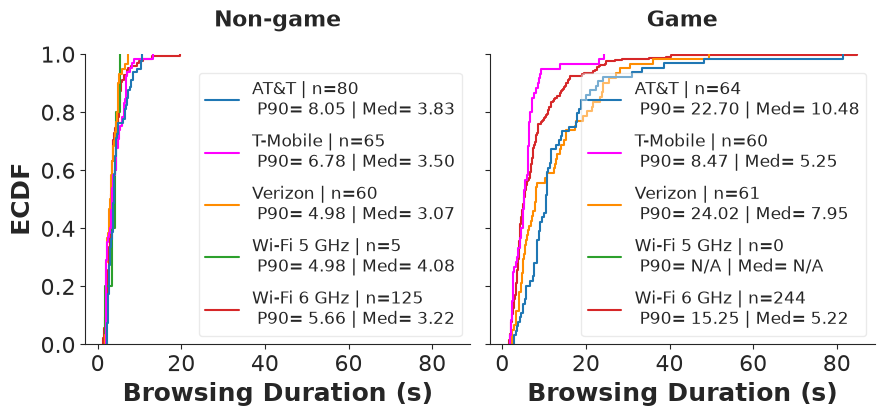

[SUCCESS] Completed: Browsing Duration ((s))


In [15]:
# Create a copy for conversions
df_plot_ready = df_browser_merged.copy()

# Apply all conversions
df_plot_ready['Round Trip Time_s'] = df_plot_ready['Round Trip Time'] / 1000
df_plot_ready['Time To First Byte_s'] = df_plot_ready['Time To First Byte'] / 1000
df_plot_ready['Access Duration_s'] = df_plot_ready['Access Duration'] / 1000
df_plot_ready['IP Throughput_Gbps'] = df_plot_ready['IP Throughput'] / 1000
df_plot_ready['Kbytes In First Second_MBps'] = df_plot_ready['Kbytes In First Second'] / 1000
df_plot_ready['Size of Webpage_MB'] = df_plot_ready['Size of Webpage'] / 1000

# Time To First Byte stays in ms (no conversion needed)
# Browsing Duration and Download Duration are already in seconds

print("[DEBUG] Created converted columns:")
print("  - Round Trip Time_s (RTT in seconds)")
print("  - Access Duration_s (from ms to s)")
print("  - IP Throughput_Gbps (from Mbps to Gbps)")
print("  - Kbytes In First Second_MBps (from KB/s to MB/s)")
print("  - Size of Webpage_MB (from KB to MB)")
print("  - Time To First Byte_s (from ms to s)")

# Define all metrics with their display names and units
metrics_to_plot = {
    # 'Round Trip Time': '(ms)',           # Original RTT in ms
    # # 'Round Trip Time_s': '(s)',          # RTT in seconds
    # # 'Time To First Byte': '(ms)',        # TTFB in ms
    # 'Time To First Byte_s': '(s)',        # TTFB in s
    'Browsing Duration': '(s)',          # Already in seconds
    # # 'Download Duration': '(s)',          # Already in seconds
    # # 'Access Duration_s': '(s)',          # Converted to seconds
    # 'IP Throughput': '(Mbps)',           # Original in Mbps
    # # 'IP Throughput_Gbps': '(Gbps)',      # Converted to Gbps
    # 'Kbytes In First Second_MBps': '(MB/s)',  # Converted to MB/s
    # # # # 'Size of Webpage_MB': '(MB)',        # Converted to MB
    # 'Number of Resources': '',
    # 'Number of Images': '',
    # 'Number of Redirections': '',
    # # 'Number of Resources not loaded': '',
}

# Display names for cleaner labels
display_names = {
    'Round Trip Time': 'Round Trip Time',
    'Round Trip Time_s': 'Round Trip Time',
    'Time To First Byte': 'Time to First Byte',
    'Browsing Duration': 'Browsing Duration',
    'Download Duration': 'Download Duration',
    'Access Duration_s': 'Access Duration',
    'IP Throughput': 'IP Throughput',
    'IP Throughput_Gbps': 'IP Throughput',
    'Kbytes In First Second_MBps': 'Bytes in First Second',
    'Size of Webpage_MB': 'Size of Webpage',
    'Number of Resources': 'Number of Resources',
    'Number of Images': 'Number of Images',
    'Number of Redirections': 'Number of Redirections',
    'Number of Resources not loaded': 'Number of Resources not loaded',
}

# Loop through all metrics
for metric_col, unit in metrics_to_plot.items():
    if metric_col not in df_plot_ready.columns:
        print(f"[WARNING] Column '{metric_col}' not found, skipping...")
        continue
    
    display_name = display_names.get(metric_col, metric_col.replace('_s', '').replace('_MB', '').replace('_Mbps', ''))
    
    print(f"\n[DEBUG] Plotting: {display_name} ({unit}) using column '{metric_col}'")
    
    try:
        g = plot_ecdf_by_split(
            df=df_plot_ready,
            metric_col=metric_col,
            metric_unit=unit,
            split_col='Label',
            rat_col='operator',
            output_dir=OUTPUT_DIR,
            op_color_map=OP_COLOR_MAP,
            collection_hosts=['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com'],
            x_label=f'{display_name} {unit}',
            y_label="ECDF",
            fig_height=4.5,
            fig_aspect=0.85,
            # fig_height=4,
            # fig_aspect=1.3,
            title_fontsize=16,
            axis_fontsize=16,

            # title_fontsize=18,
            # axis_fontsize=18,
            dpi=300
        )
        plt.close()
        print(f"[SUCCESS] Completed: {display_name} ({unit})")
        
    except Exception as e:
        print(f"[ERROR] Failed: {display_name} ({unit}) - {e!s}")

# C- Text Output

In [16]:
df_browser_gameday = combined_df[
    (combined_df['Label'] == 'Game')
    & (combined_df['Test Status'] == 'Completed')
]
df_browser_postgame = combined_df[
    (combined_df['Label'] == 'Non-game')
    & (combined_df['Test Status'] == 'Completed')
]

In [17]:
df_browser_postgame['Time'] = pd.to_datetime(df_browser_postgame['Time'])
df_browser_postgame['Time'].describe()

count                                 335
mean     2026-02-26 12:06:15.887782-05:00
min      2026-02-26 11:25:20.590000-05:00
25%      2026-02-26 11:47:32.364500-05:00
50%      2026-02-26 12:07:18.416000-05:00
75%      2026-02-26 12:25:45.534500-05:00
max      2026-02-26 12:45:38.776000-05:00
Name: Time, dtype: object

### B: Overview

In [18]:
COLLECTION_HOST = ['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com']
df_browser_gameday = df_browser_gameday[df_browser_gameday['Host'].isin(COLLECTION_HOST)].copy()
df_browser_postgame = df_browser_postgame[df_browser_postgame['Host'].isin(COLLECTION_HOST)].copy()

In [19]:
cols = ['Browsing Duration', 'Time To First Byte', 'Number of Resources not loaded', 'Number of Resources', 'Round Trip Time (RTT)', 'IP Throughput', 'Access Duration',]

# Use + to combine lists on the fly
print('Gameday' + '='*30)
display(df_browser_gameday[cols + ['Size of Webpage']].describe())
print('Postgameday' + '='*30)
display(df_browser_postgame[cols + ['Size of Webpage']].describe())

Gameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Number of Resources,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,429.000000,413.000000,429.000000,429.000000,429.000000,4.100000e+02,413.000000,0.0
mean,8.975599,1211.912833,0.202797,130.871795,120.634033,1.197845e+05,651.627119,NaN
std,8.997338,2097.488987,0.570613,100.304000,348.298446,1.168926e+06,992.520882,NaN
min,1.510000,74.000000,0.000000,34.000000,0.000000,6.742497e+02,53.000000,NaN
25%,3.918000,417.000000,0.000000,55.000000,35.000000,5.690191e+03,267.000000,NaN
50%,6.223000,583.000000,0.000000,93.000000,61.000000,2.022860e+04,383.000000,NaN
75%,10.654000,912.000000,0.000000,229.000000,101.000000,5.042710e+04,608.000000,NaN
max,84.879000,23082.000000,4.000000,829.000000,4226.000000,2.309386e+07,9223.000000,NaN


Postgameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Number of Resources,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,335.000000,331.000000,335.000000,335.000000,335.000000,332.000000,331.000000,335.000000
mean,3.928430,585.504532,0.292537,133.988060,49.110448,16869.208905,315.060423,5550.577854
std,2.178767,694.038801,0.703565,94.252685,30.251091,27993.236503,292.043286,9472.886046
min,1.221000,96.000000,0.000000,24.000000,14.000000,1515.708744,55.000000,1113.184000
25%,2.446000,354.000000,0.000000,58.000000,32.000000,5726.978123,197.000000,2362.463500
50%,3.408000,463.000000,0.000000,111.000000,44.000000,9950.817948,281.000000,3838.450000
75%,4.766000,623.500000,0.000000,221.000000,58.000000,21360.362541,360.500000,9776.370500
max,19.732000,5889.000000,3.000000,814.000000,437.000000,441848.682231,4772.000000,164312.143000


### B: Operator-wise

In [20]:
# df_browser_postgame['operator'] = df_browser_postgame['Operator']

In [21]:
att_gameday = df_browser_gameday[df_browser_gameday['operator'] == 'AT&T'].copy()
att_postgame = df_browser_postgame[df_browser_postgame['operator'] == 'AT&T'].copy()

cols = ['Browsing Duration', 'Time To First Byte', 'Number of Resources not loaded', 'Round Trip Time (RTT)', 'IP Throughput', 'Access Duration', ]

# Use + to combine lists on the fly
print('-'*50+'[AT&T]'+'-'*50)
print('Gameday' + '='*30)
display(att_gameday[cols + ['Size of Webpage']].describe())
print('Postgameday' + '='*30)
display(att_postgame[cols + ['Size of Webpage']].describe())

--------------------------------------------------[AT&T]--------------------------------------------------
Gameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,0.0
mean,13.535234,1356.468750,0.187500,77.390625,14907.877323,711.062500,NaN
std,12.157988,1940.243619,0.467177,75.117816,21838.013875,1033.820897,NaN
min,2.807000,308.000000,0.000000,28.000000,674.249733,149.000000,NaN
25%,7.475500,514.250000,0.000000,41.000000,3794.167540,314.500000,NaN
50%,10.480500,691.000000,0.000000,55.000000,6718.149189,391.000000,NaN
75%,16.485750,1209.250000,0.000000,75.250000,17225.941445,595.000000,NaN
max,81.443000,12024.000000,2.000000,411.000000,107031.617312,6974.000000,NaN


Postgameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,80.000000,80.000000,80.00000,80.000000,80.000000,80.000000,80.000000
mean,4.492913,642.062500,0.26250,58.862500,12097.046489,364.750000,4794.188512
std,2.238417,188.907006,0.67023,8.455009,8351.140250,117.283439,3114.689378
min,2.202000,319.000000,0.00000,50.000000,2477.116205,136.000000,1205.069000
25%,2.787000,529.750000,0.00000,53.000000,4750.797707,285.750000,3359.588500
50%,3.825500,611.000000,0.00000,57.000000,9660.177364,317.500000,4157.070500
75%,4.800500,725.000000,0.00000,63.000000,20835.173897,411.250000,4568.438000
max,10.642000,1427.000000,2.00000,105.000000,32713.429949,629.000000,11946.851000


In [22]:
tmo_gameday = df_browser_gameday[df_browser_gameday['operator'] == 'T-Mobile'].copy()
tmo_postgame = df_browser_postgame[df_browser_postgame['operator'] == 'T-Mobile'].copy()

cols = ['Browsing Duration', 'Time To First Byte', 'Number of Resources not loaded', 'Round Trip Time (RTT)', 'IP Throughput', 'Access Duration', ]

# Use + to combine lists on the fly
print('-'*50+'[T-MOBILE]'+'-'*50)
print('Gameday' + '='*30)
display(tmo_gameday[cols + ['Size of Webpage']].describe())
print('Postgameday' + '='*30)
display(tmo_postgame[cols + ['Size of Webpage']].describe())

--------------------------------------------------[T-MOBILE]--------------------------------------------------
Gameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,60.000000,59.000000,60.000000,60.000000,60.000000,59.000000,0.0
mean,5.700817,562.762712,0.350000,69.650000,54762.649307,408.694915,NaN
std,4.095458,229.483478,0.798834,39.890029,89173.746205,219.997590,NaN
min,1.849000,279.000000,0.000000,27.000000,964.000575,103.000000,NaN
25%,2.731500,395.500000,0.000000,43.000000,8372.126022,275.000000,NaN
50%,5.246000,504.000000,0.000000,56.500000,27432.045309,352.000000,NaN
75%,6.440750,635.000000,0.000000,76.500000,72085.791667,470.500000,NaN
max,24.312000,1597.000000,4.000000,212.000000,594724.105263,1441.000000,NaN


Postgameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,4.040769,563.846154,0.246154,49.661538,20353.648496,317.015385,5781.149231
std,2.241036,638.747657,0.638131,29.505443,22647.647591,172.854481,4560.818473
min,1.885000,188.000000,0.000000,30.000000,2499.430111,76.000000,1113.184000
25%,2.047000,356.000000,0.000000,33.000000,4197.088032,216.000000,2313.325000
50%,3.502000,454.000000,0.000000,36.000000,7011.674615,240.000000,3232.019000
75%,5.315000,651.000000,0.000000,40.000000,25669.301868,382.000000,11361.024000
max,13.144000,5404.000000,3.000000,116.000000,70371.920477,656.000000,12521.125000


In [23]:
vzw_gameday = df_browser_gameday[df_browser_gameday['operator'] == 'Verizon'].copy()
vzw_postgame = df_browser_postgame[df_browser_postgame['operator'] == 'Verizon'].copy()

cols = ['Browsing Duration', 'Time To First Byte', 'Number of Resources not loaded', 'Round Trip Time (RTT)', 'IP Throughput', 'Access Duration', ]

# Use + to combine lists on the fly
print('-'*50+'[VERIZON]'+'-'*50)
print('Gameday' + '='*30)
display(vzw_gameday[cols + ['Size of Webpage']].describe())
print('Postgameday' + '='*30)
display(vzw_postgame[cols + ['Size of Webpage']].describe())

--------------------------------------------------[VERIZON]--------------------------------------------------
Gameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,61.000000,61.000000,61.000000,61.000000,57.000000,61.000000,0.0
mean,12.011590,2192.147541,0.098361,152.885246,24712.294952,939.196721,NaN
std,9.685323,3486.909438,0.351422,428.742584,43190.678768,1203.186420,NaN
min,2.226000,278.000000,0.000000,0.000000,919.261129,150.000000,NaN
25%,4.892000,434.000000,0.000000,35.000000,3253.825279,239.000000,NaN
50%,7.950000,750.000000,0.000000,48.000000,12516.471412,415.000000,NaN
75%,17.299000,2339.000000,0.000000,81.000000,20070.118593,1153.000000,NaN
max,49.447000,23082.000000,2.000000,3016.000000,213413.595376,5766.000000,NaN


Postgameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,3.331350,523.266667,0.450000,31.700000,16102.220985,196.316667,5182.161767
std,1.392622,906.007443,0.928367,4.865304,12619.169174,61.971697,3782.375567
min,1.787000,96.000000,0.000000,23.000000,4906.953620,55.000000,1144.288000
25%,2.064500,296.250000,0.000000,28.000000,6122.773906,160.000000,2379.721750
50%,3.065500,349.000000,0.000000,30.500000,10328.684837,188.500000,3629.391500
75%,4.325500,414.500000,0.000000,33.250000,21716.884505,220.250000,9533.347000
max,7.160000,5354.000000,3.000000,45.000000,51988.630073,340.000000,11980.469000


In [24]:
wifi6_gameday = df_browser_gameday[df_browser_gameday['operator'] == 'Wi-Fi 6 GHz'].copy()
wifi6_postgame = df_browser_postgame[df_browser_postgame['operator'] == 'Wi-Fi 6 GHz'].copy()

cols = ['Browsing Duration', 'Time To First Byte', 'Number of Resources not loaded', 'Round Trip Time (RTT)', 'IP Throughput', 'Access Duration', ]

# Use + to combine lists on the fly
print('-'*50+'[Wi-Fi 6 GHz]'+'-'*50)
print('Gameday' + '='*30)
display(wifi6_gameday[cols + ['Size of Webpage']].describe())
print('Postgameday' + '='*30)
display(wifi6_postgame[cols + ['Size of Webpage']].describe())

--------------------------------------------------[Wi-Fi 6 GHz]--------------------------------------------------
Gameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,244.000000,229.000000,244.000000,244.000000,2.290000e+02,229.000000,0.0
mean,7.825906,1077.650655,0.196721,136.450820,1.897956e+05,621.004367,NaN
std,8.078403,1818.405273,0.568578,405.937103,1.561114e+06,1025.749437,NaN
min,1.510000,74.000000,0.000000,15.000000,8.697165e+02,53.000000,NaN
25%,3.599500,387.000000,0.000000,28.000000,8.181529e+03,248.000000,NaN
50%,5.222000,573.000000,0.000000,73.500000,3.058071e+04,382.000000,NaN
75%,8.619250,855.000000,0.000000,111.000000,7.080306e+04,596.000000,NaN
max,84.879000,12433.000000,3.000000,4226.000000,2.309386e+07,9223.000000,NaN


Postgameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,125.000000,121.000000,125.000000,125.00000,122.000000,121.000000,125.000000
mean,3.799992,598.305785,0.264000,51.19200,18810.523768,342.801653,6133.889976
std,2.370237,820.639211,0.636827,41.48274,41482.726572,444.577020,14723.111353
min,1.221000,222.000000,0.000000,14.00000,1515.708744,72.000000,1144.289000
25%,2.492000,343.000000,0.000000,32.00000,7213.211690,187.000000,2355.269000
50%,3.219000,447.000000,0.000000,46.00000,10804.998470,282.000000,3655.571000
75%,4.496000,567.000000,0.000000,60.00000,18422.300277,381.000000,5992.546000
max,19.732000,5889.000000,3.000000,437.00000,441848.682231,4772.000000,164312.143000


In [25]:
wifi5_gameday = df_browser_gameday[df_browser_gameday['operator'] == 'Wi-Fi 5 GHz'].copy()
wifi5_postgame = df_browser_postgame[df_browser_postgame['operator'] == 'Wi-Fi 5 GHz'].copy()

cols = ['Browsing Duration', 'Time To First Byte', 'Number of Resources not loaded', 'Round Trip Time (RTT)', 'IP Throughput', 'Access Duration', ]

# Use + to combine lists on the fly
print('-'*50+'[Wi-Fi 5 GHz]'+'-'*50)
print('Gameday' + '='*30)
display(wifi5_gameday[cols + ['Size of Webpage']].describe())
print('Postgameday' + '='*30)
display(wifi5_postgame[cols + ['Size of Webpage']].describe())

--------------------------------------------------[Wi-Fi 5 GHz]--------------------------------------------------
Gameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Postgameday==============================


,Browsing Duration,Time To First Byte,Number of Resources not loaded,Round Trip Time (RTT),IP Throughput,Access Duration,Size of Webpage
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.812200,399.200000,0.200000,42.800000,9761.865266,248.200000,4493.569400
std,1.356676,132.677052,0.447214,27.179036,4169.985518,103.521495,3352.850499
min,1.685000,243.000000,0.000000,19.000000,6774.233491,122.000000,1199.040000
25%,3.515000,283.000000,0.000000,23.000000,7744.045412,157.000000,3073.419000
50%,4.076000,453.000000,0.000000,28.000000,8342.285643,290.000000,3888.320000
75%,4.477000,455.000000,0.000000,66.000000,8857.230377,309.000000,4188.865000
max,5.308000,562.000000,1.000000,78.000000,17091.531405,363.000000,10118.203000


### B: Descriptive Statistics

In [26]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats


def ultra_simple_load_test(df, metric_col, metric_name, unit, ci_level=0.95, debug=False):
    """
    Statistical load test comparing Gameday vs PostGame periods
    
    Parameters:
    -----------
    df : DataFrame
        Contains 'Period' column and the metric column
    metric_col : str
        Column name in df for the metric (e.g., 'Time To First Byte_s')
    metric_name : str
        Display name for the metric (e.g., 'Time to First Byte')
    unit : str
        Unit for the metric (e.g., 's', 'ms', 'Gbps', 'MB/s')
    ci_level : float
        Confidence level for intervals (default 0.95)
    debug : bool
        Print debug information
    """
    
    if debug:
        print(f"[DEBUG] Starting analysis for: {metric_name}")
        print(f"[DEBUG] Column: {metric_col}, Unit: {unit}")
        print(f"[DEBUG] DataFrame shape: {df.shape}")
        print(f"[DEBUG] Columns available: {df.columns.tolist()}")
    
    # Filter valid samples
    valid = df[
        (df['Test Status'] == 'Completed') & 
        (df[metric_col].notna())
    ].copy()
    
    if debug:
        print(f"[DEBUG] Valid samples after filtering: {len(valid)}")
        print(f"[DEBUG] Test Status counts: {df['Test Status'].value_counts().to_dict()}")
        print(f"[DEBUG] Period counts in valid: {valid['Period'].value_counts().to_dict()}")
    
    if len(valid) == 0:
        return {"Error": "No valid samples"}
    
    # Split by period
    gd = valid[valid['Period'] == 'Gameday'][metric_col]
    pg = valid[valid['Period'] == 'PostGame'][metric_col]
    
    if debug:
        print(f"[DEBUG] Gameday samples: {len(gd)}")
        print(f"[DEBUG] PostGame samples: {len(pg)}")
        print(f"[DEBUG] Gameday stats - min: {gd.min():.4f}, max: {gd.max():.4f}, median: {gd.median():.4f}")
        print(f"[DEBUG] PostGame stats - min: {pg.min():.4f}, max: {pg.max():.4f}, median: {pg.median():.4f}")
    
    # # Minimum sample size check
    # if len(gd) < 1 or len(pg) < 1:
    #     return {"Error": f"Insufficient samples: GD={len(gd)}, PG={len(pg)} (need at least 10 each)"}
    
    # Mann-Whitney U test
    try:
        _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
        if debug:
            print(f"[DEBUG] Mann-Whitney U test p-value: {pval:.6f}")
    except Exception as e:
        if debug:
            print(f"[DEBUG] Mann-Whitney test failed: {e!s}")
        return {"Error": f"Statistical test failed: {e!s}"}
    
    # Hodges-Lehmann estimator and bootstrap CI
    try:
        # Calculate all pairwise differences
        differences = np.array([x - y for x in gd for y in pg])
        hl_estimate = np.median(differences)
        
        if debug:
            print(f"[DEBUG] Hodges-Lehmann estimate: {hl_estimate:.6f}")
            print(f"[DEBUG] Number of pairwise differences: {len(differences):,}")
        
        # Bootstrap for confidence interval
        n_bootstrap = 1000
        bootstrap_diffs = []
        
        for i in range(n_bootstrap):
            gd_boot = np.random.choice(gd, size=len(gd), replace=True)
            pg_boot = np.random.choice(pg, size=len(pg), replace=True)
            boot_diffs = np.array([x - y for x in gd_boot for y in pg_boot])
            bootstrap_diffs.append(np.median(boot_diffs))
            
            if debug and (i + 1) % 200 == 0:
                print(f"[DEBUG] Bootstrap progress: {i+1}/{n_bootstrap}")
        
        ci_lower = np.percentile(bootstrap_diffs, (1 - ci_level) / 2 * 100)
        ci_upper = np.percentile(bootstrap_diffs, (1 + ci_level) / 2 * 100)
        
        if debug:
            print(f"[DEBUG] {ci_level*100:.0f}% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
        
    except Exception as e:
        if debug:
            print(f"[DEBUG] Bootstrap/HL estimation failed: {e!s}")
        hl_estimate = None
        ci_lower = None
        ci_upper = None
    
    # Calculate statistics
    median_gd = gd.median()
    median_pg = pg.median()
    delta_median = median_gd - median_pg
    
    # For ratio, handle potential zero values
    if median_pg != 0:
        ratio = median_gd / median_pg
    else:
        ratio = np.nan if median_gd == 0 else np.inf
    
    result = {
        'Metric': metric_name,
        'Unit': unit,
        'Metric_Column': metric_col,
        'N_GD': len(gd), 
        'N_PG': len(pg),
        'Med_GD': median_gd, 
        'Med_PG': median_pg,
        'Mean_GD': gd.mean(),
        'Mean_PG': pg.mean(),
        'Std_GD': gd.std(),
        'Std_PG': pg.std(),
        'P10_GD': gd.quantile(0.10), 
        'P10_PG': pg.quantile(0.10),
        'P90_GD': gd.quantile(0.90), 
        'P90_PG': pg.quantile(0.90),
        'P95_GD': gd.quantile(0.95),
        'P95_PG': pg.quantile(0.95),
        'P99_GD': gd.quantile(0.99), 
        'P99_PG': pg.quantile(0.99),
        'Delta_Median': delta_median,
        'Delta_Mean': gd.mean() - pg.mean(),
        'Delta_HL': hl_estimate,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'CI_Level': ci_level,
        'Ratio': ratio,
        'P_Value': pval,
        'Significant': pval < 0.05
    }
    
    if debug:
        print(f"[DEBUG] Analysis complete for {metric_name}")
        print(f"[DEBUG] Significant: {result['Significant']} (p={pval:.4f})")
    
    return result

def format_stat_result(res, decimal_places=3):
    """Format statistical result for text output"""
    if 'Error' in res:
        return f"  ERROR: {res['Error']}"
    
    # Determine decimal formatting based on value magnitude
    if abs(res['Med_GD']) < 0.01 and res['Med_GD'] != 0:
        fmt = '{:.6f}'
    else:
        fmt = f'{{:.{decimal_places}f}}'
    
    lines = []
    lines.append(f"\n{'='*60}")
    lines.append(f"[METRIC] {res['Metric']} ({res['Unit']})")
    lines.append(f"{'='*60}")
    lines.append(f"  Sample Sizes:     GD={res['N_GD']}, PG={res['N_PG']}")
    lines.append("")
    lines.append("  [CENTRAL TENDENCY]")
    lines.append(f"    Median:          GD={fmt.format(res['Med_GD'])} {res['Unit']}, PG={fmt.format(res['Med_PG'])} {res['Unit']}")
    lines.append(f"    Mean:            GD={fmt.format(res['Mean_GD'])} {res['Unit']}, PG={fmt.format(res['Mean_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [VARIABILITY]")
    lines.append(f"    Std Dev:         GD={fmt.format(res['Std_GD'])} {res['Unit']}, PG={fmt.format(res['Std_PG'])} {res['Unit']}")
    lines.append(f"    P10:             GD={fmt.format(res['P10_GD'])} {res['Unit']}, PG={fmt.format(res['P10_PG'])} {res['Unit']}")
    lines.append(f"    P90:             GD={fmt.format(res['P90_GD'])} {res['Unit']}, PG={fmt.format(res['P90_PG'])} {res['Unit']}")
    lines.append(f"    P95:             GD={fmt.format(res['P95_GD'])} {res['Unit']}, PG={fmt.format(res['P95_PG'])} {res['Unit']}")
    lines.append(f"    P99:             GD={fmt.format(res['P99_GD'])} {res['Unit']}, PG={fmt.format(res['P99_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [DIFFERENCES]")
    lines.append(f"    Delta Median:    {res['Delta_Median']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Delta Mean:      {res['Delta_Mean']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Ratio (GD/PG):   {res['Ratio']:.3f}x")
    
    if res['Delta_HL'] is not None:
        lines.append(f"    Hodges-Lehmann:  {res['Delta_HL']:+.{decimal_places}f} {res['Unit']}")
        lines.append(f"    {res['CI_Level']*100:.0f}% CI:           [{fmt.format(res['CI_Lower'])}, {fmt.format(res['CI_Upper'])}] {res['Unit']}")
    
    lines.append("")
    lines.append("  [STATISTICAL TEST] Mann-Whitney U")
    significance = "[SIGNIFICANT]" if res['Significant'] else "[NOT SIGNIFICANT]"
    lines.append(f"    {significance} (p={res['P_Value']:.6f})")
    
    if res['Significant']:
        if res['Delta_Median'] > 0:
            lines.append(f"    -> Gameday is WORSE (higher values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
        else:
            lines.append(f"    -> Gameday is BETTER (lower values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
    
    return '\n'.join(lines)

def run_all_load_tests(df_all_carriers, metrics_config, output_dir, debug=False):
    """
    Run load tests for all carriers and metrics
    
    Parameters:
    -----------
    df_all_carriers : dict
        Dictionary with carrier names as keys and DataFrames as values
    metrics_config : dict
        Dictionary with column names as keys and (display_name, unit) as values
    output_dir : Path or str
        Directory to save output file
    debug : bool
        Enable debug printing
    """
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    output_file = output_dir / 'BrowsingStatistics.txt'
    
    # Open file for writing
    with open(output_file, 'w', encoding='utf-8') as f:
        # Write header
        f.write("="*80 + "\n")
        f.write("BROWSING PERFORMANCE STATISTICS - LOAD TEST ANALYSIS\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n")
        f.write("\nAnalysis compares Gameday vs PostGame periods using Mann-Whitney U test\n")
        f.write("Confidence Level: 95% (bootstrap CI for Hodges-Lehmann estimator)\n")
        f.write("\n")
        
        # Also print to console
        print("\n" + "="*80)
        print("RUNNING LOAD TESTS FOR ALL CARRIERS")
        print("="*80)
        
        all_results = {}
        
        for carrier_name, df in df_all_carriers.items():
            print(f"\n[CARRIER] {carrier_name}")
            f.write(f"\n{'#'*80}\n")
            f.write(f"# CARRIER: {carrier_name}\n")
            f.write(f"{'#'*80}\n")
            
            carrier_results = {}
            
            for metric_col, (metric_name, unit) in metrics_config.items():
                if debug:
                    print(f"  [DEBUG] Testing {metric_name}...")
                
                # Check if column exists in dataframe
                if metric_col not in df.columns:
                    error_msg = f"  ERROR: Column '{metric_col}' not found in dataframe"
                    print(error_msg)
                    f.write(f"\n{metric_name}: {error_msg}\n")
                    continue
                
                # Run test
                result = ultra_simple_load_test(
                    df, metric_col, metric_name, unit, 
                    ci_level=0.95, debug=debug
                )
                
                # Format and write result
                formatted_result = format_stat_result(result)
                print(formatted_result)
                f.write(formatted_result + "\n")
                
                carrier_results[metric_name] = result
            
            all_results[carrier_name] = carrier_results
            
            # Add summary for this carrier
            significant_count = sum(1 for r in carrier_results.values() 
                                   if isinstance(r, dict) and r.get('Significant', False))
            total_tests = len([r for r in carrier_results.values() if isinstance(r, dict)])
            
            summary = f"\n[SUMMARY] {carrier_name}: {significant_count}/{total_tests} metrics showed significant differences\n"
            print(summary)
            f.write(summary)
        
        # Write footer
        f.write("\n" + "="*80 + "\n")
        f.write("END OF ANALYSIS\n")
        f.write("="*80 + "\n")
    
    print(f"\n[SUCCESS] Results saved to: {output_file}")
    return all_results

In [27]:
# Assign period labels and combine per carrier
carriers_data = {
    'AT&T': pd.concat([
        att_gameday.assign(Period='Gameday'), 
        att_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'T-Mobile': pd.concat([
        tmo_gameday.assign(Period='Gameday'), 
        tmo_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Verizon': pd.concat([
        vzw_gameday.assign(Period='Gameday'), 
        vzw_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 6 GHz': pd.concat([
        wifi6_gameday.assign(Period='Gameday'), 
        wifi6_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 5GHz': pd.concat([
        wifi5_gameday.assign(Period='Gameday'), 
        wifi5_postgame.assign(Period='PostGame')
    ], ignore_index=True),
}
metrics_config = {
    'Round Trip Time (RTT)': ('Round Trip Time', 'ms'),
    'Time To First Byte': ('Time to First Byte', 'ms'),
    'Browsing Duration': ('Browsing Duration', 's'),
    # 'Download Duration': ('Download Duration', 's'),
    'Access Duration': ('Access Duration', 'ms'),
    'IP Throughput': ('IP Throughput', 'Mbps'),
    'Kbytes In First Second': ('Bytes in First Second', 'KB/s'),
}

# df_plot_ready = df_browser_merged.copy()

# # Apply all conversions
# df_plot_ready['Round Trip Time_s'] = df_plot_ready['Round Trip Time'] / 1000
# df_plot_ready['Time To First Byte_s'] = df_plot_ready['Time To First Byte'] / 1000
# df_plot_ready['Access Duration_s'] = df_plot_ready['Access Duration'] / 1000
# df_plot_ready['IP Throughput_Gbps'] = df_plot_ready['IP Throughput'] / 1000
# df_plot_ready['Kbytes In First Second_MBps'] = df_plot_ready['Kbytes In First Second'] / 1000
# df_plot_ready['Size of Webpage_MB'] = df_plot_ready['Size of Webpage'] / 1000

# # Time To First Byte stays in ms (no conversion needed)
# # Browsing Duration and Download Duration are already in seconds

# print("[DEBUG] Created converted columns:")
# print(f"  - Round Trip Time_s (RTT in seconds)")
# print(f"  - Access Duration_s (from ms to s)")
# print(f"  - IP Throughput_Gbps (from Mbps to Gbps)")
# print(f"  - Kbytes In First Second_MBps (from KB/s to MB/s)")
# print(f"  - Size of Webpage_MB (from KB to MB)")
# print(f"  - Time To First Byte_s (from ms to s)")

# Run the tests
results = run_all_load_tests(
    df_all_carriers=carriers_data,
    metrics_config=metrics_config,
    output_dir=OUTPUT_DIR,
    debug=False
)


RUNNING LOAD TESTS FOR ALL CARRIERS

[CARRIER] AT&T



[METRIC] Round Trip Time (ms)
  Sample Sizes:     GD=64, PG=80

  [CENTRAL TENDENCY]
    Median:          GD=55.000 ms, PG=57.000 ms
    Mean:            GD=77.391 ms, PG=58.862 ms

  [VARIABILITY]
    Std Dev:         GD=75.118 ms, PG=8.455 ms
    P10:             GD=36.000 ms, PG=52.000 ms
    P90:             GD=111.000 ms, PG=67.100 ms
    P95:             GD=276.200 ms, PG=70.150 ms
    P99:             GD=388.950 ms, PG=88.410 ms

  [DIFFERENCES]
    Delta Median:    -2.000 ms
    Delta Mean:      +18.528 ms
    Ratio (GD/PG):   0.965x
    Hodges-Lehmann:  -4.000 ms
    95% CI:           [-11.000, 7.000] ms

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=0.397066)



[METRIC] Time to First Byte (ms)
  Sample Sizes:     GD=64, PG=80

  [CENTRAL TENDENCY]
    Median:          GD=691.000 ms, PG=611.000 ms
    Mean:            GD=1356.469 ms, PG=642.062 ms

  [VARIABILITY]
    Std Dev:         GD=1940.244 ms, PG=188.907 ms
    P10:             GD=401.300 ms, PG=444.800 ms
    P90:             GD=2916.400 ms, PG=836.400 ms
    P95:             GD=5162.550 ms, PG=916.250 ms
    P99:             GD=8940.780 ms, PG=1427.000 ms

  [DIFFERENCES]
    Delta Median:    +80.000 ms
    Delta Mean:      +714.406 ms
    Ratio (GD/PG):   1.131x
    Hodges-Lehmann:  +75.000 ms
    95% CI:           [-9.000, 195.050] ms

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=0.075555)



[METRIC] Browsing Duration (s)
  Sample Sizes:     GD=64, PG=80

  [CENTRAL TENDENCY]
    Median:          GD=10.480 s, PG=3.825 s
    Mean:            GD=13.535 s, PG=4.493 s

  [VARIABILITY]
    Std Dev:         GD=12.158 s, PG=2.238 s
    P10:             GD=4.627 s, PG=2.485 s
    P90:             GD=22.703 s, PG=8.051 s
    P95:             GD=33.024 s, PG=9.395 s
    P99:             GD=60.482 s, PG=10.636 s

  [DIFFERENCES]
    Delta Median:    +6.655 s
    Delta Mean:      +9.042 s
    Ratio (GD/PG):   2.740x
    Hodges-Lehmann:  +6.189 s
    95% CI:           [4.673, 7.657] s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.000000)
    -> Gameday is WORSE (higher values) by 6.655 s



[METRIC] Access Duration (ms)
  Sample Sizes:     GD=64, PG=80

  [CENTRAL TENDENCY]
    Median:          GD=391.000 ms, PG=317.500 ms
    Mean:            GD=711.062 ms, PG=364.750 ms

  [VARIABILITY]
    Std Dev:         GD=1033.821 ms, PG=117.283 ms
    P10:             GD=257.800 ms, PG=268.400 ms
    P90:             GD=1054.300 ms, PG=553.300 ms
    P95:             GD=2450.150 ms, PG=587.000 ms
    P99:             GD=5223.230 ms, PG=629.000 ms

  [DIFFERENCES]
    Delta Median:    +73.500 ms
    Delta Mean:      +346.312 ms
    Ratio (GD/PG):   1.231x
    Hodges-Lehmann:  +67.000 ms
    95% CI:           [19.000, 129.000] ms

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.003746)
    -> Gameday is WORSE (higher values) by 73.500 ms


...


[METRIC] Bytes in First Second (KB/s)
  Sample Sizes:     GD=229, PG=121

  [CENTRAL TENDENCY]
    Median:          GD=743.098 KB/s, PG=1300.776 KB/s
    Mean:            GD=1025.690 KB/s, PG=2214.581 KB/s

  [VARIABILITY]
    Std Dev:         GD=1085.369 KB/s, PG=5003.613 KB/s
    P10:             GD=212.911 KB/s, PG=448.552 KB/s
    P90:             GD=1924.978 KB/s, PG=3352.422 KB/s
    P95:             GD=2602.826 KB/s, PG=4803.483 KB/s
    P99:             GD=5805.041 KB/s, PG=9429.782 KB/s

  [DIFFERENCES]
    Delta Median:    -557.679 KB/s
    Delta Mean:      -1188.891 KB/s
    Ratio (GD/PG):   0.571x
    Hodges-Lehmann:  -568.839 KB/s
    95% CI:           [-755.390, -379.716] KB/s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.000000)
    -> Gameday is BETTER (lower values) by 557.679 KB/s

[SUMMARY] Wi-Fi 6 GHz: 6/6 metrics showed significant differences


[CARRIER] Wi-Fi 5GHz

[METRIC] Round Trip Time (ms)
  Sample Sizes:     GD=0, PG=5

  [CENTRAL TENDENCY]
 

/tmp/ipykernel_29292/1588375230.py:65: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_29292/1588375230.py:65: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
/home/analisis/repo


[METRIC] Browsing Duration (s)
  Sample Sizes:     GD=0, PG=5

  [CENTRAL TENDENCY]
    Median:          GD=nan s, PG=4.076 s
    Mean:            GD=nan s, PG=3.812 s

  [VARIABILITY]
    Std Dev:         GD=nan s, PG=1.357 s
    P10:             GD=nan s, PG=2.417 s
    P90:             GD=nan s, PG=4.976 s
    P95:             GD=nan s, PG=5.142 s
    P99:             GD=nan s, PG=5.275 s

  [DIFFERENCES]
    Delta Median:    +nan s
    Delta Mean:      +nan s
    Ratio (GD/PG):   nanx
    Hodges-Lehmann:  +nan s
    95% CI:           [nan, nan] s

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=nan)

[METRIC] Access Duration (ms)
  Sample Sizes:     GD=0, PG=5

  [CENTRAL TENDENCY]
    Median:          GD=nan ms, PG=290.000 ms
    Mean:            GD=nan ms, PG=248.200 ms

  [VARIABILITY]
    Std Dev:         GD=nan ms, PG=103.521 ms
    P10:             GD=nan ms, PG=136.000 ms
    P90:             GD=nan ms, PG=341.400 ms
    P95:             GD=nan ms, PG=352.200 m

/tmp/ipykernel_29292/1588375230.py:65: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_29292/1588375230.py:65: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
/home/analisis/repo


[METRIC] IP Throughput (Mbps)
  Sample Sizes:     GD=0, PG=5

  [CENTRAL TENDENCY]
    Median:          GD=nan Mbps, PG=8342.286 Mbps
    Mean:            GD=nan Mbps, PG=9761.865 Mbps

  [VARIABILITY]
    Std Dev:         GD=nan Mbps, PG=4169.986 Mbps
    P10:             GD=nan Mbps, PG=7162.158 Mbps
    P90:             GD=nan Mbps, PG=13797.811 Mbps
    P95:             GD=nan Mbps, PG=15444.671 Mbps
    P99:             GD=nan Mbps, PG=16762.159 Mbps

  [DIFFERENCES]
    Delta Median:    +nan Mbps
    Delta Mean:      +nan Mbps
    Ratio (GD/PG):   nanx
    Hodges-Lehmann:  +nan Mbps
    95% CI:           [nan, nan] Mbps

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=nan)

[METRIC] Bytes in First Second (KB/s)
  Sample Sizes:     GD=0, PG=5

  [CENTRAL TENDENCY]
    Median:          GD=nan KB/s, PG=1018.344 KB/s
    Mean:            GD=nan KB/s, PG=1191.634 KB/s

  [VARIABILITY]
    Std Dev:         GD=nan KB/s, PG=509.033 KB/s
    P10:             GD=nan KB/s, PG=